## Phase 1: Run Linear Probes on Single Datasets: Phi-3-mini-4k-instruct on nq (3k)

* [Done] Variations: SE -> Acc; SE -> SE; Acc -> Acc. <br>
* [Done] Across all layers for both SLT and TBG tokens. <br>
* [Done] Binarization (best split via regression forest). <br>
* [Done] Save log of test metrics for visualization.
* [Done] Take some time to alter the llama codes for keeping residuals and attention outputs.

In [1]:
%load_ext autoreload
%autoreload 2

import os
import pickle
import yaml
import json

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import torch

from copy import deepcopy
import seaborn as sns

import wandb
os.chdir('/scratch-ssd/ms23jh/uncertainty/wandb-ref/run-20240506_040906-y4ozhtoh//files')  # path for llama2-7b on nq (2k)

Matplotlib created a temporary cache directory at /tmp/matplotlib-xyn5d7_i because the default path (/scratch-ssd/oatml/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## Utility Functions

In [2]:
# Read training generated embeddings
f = open('validation_generations.pkl', 'rb')
generations = pickle.load(f)
f.close()

# Read uncertainty measures (p-true, predictive/semantic uncertainties)
g = open('uncertainty_measures.pkl', 'rb')
measures = pickle.load(g)
g.close()

In [3]:
entropy = torch.tensor(measures['uncertainty_measures']['cluster_assignment_entropy']).to(torch.float32)  # replace semantic_entropy with cluster_assignment_entropy
print(entropy.shape, entropy)

torch.Size([2000]) tensor([2.3026, -0.0000, 1.8867,  ..., 0.9404, 0.3251, 2.3026])


In [4]:
# Define LR and MLP model structures (LR)
import torch
import torch.nn as nn
from torch.nn import Linear, ReLU, Dropout, BatchNorm1d, Sigmoid
from sklearn.linear_model import LogisticRegression, LinearRegression

class MLP(nn.Module):
    def __init__(self, in_dim, hid_dims, out_dim=1, dropout=0.5):
        super(MLP, self).__init__()
        layers = []
        
        if isinstance(hid_dims, int):
            layer_dims = [in_dim] + [hid_dims] * 2
        elif isinstance(hid_dims, list):
            layer_dims = [in_dim] + hid_dims
        else:
            raise ValueError("hid_dims must be either an integer or a list of integers")
        
        for i in range(len(layer_dims) - 1):
            layers.append(Linear(layer_dims[i], layer_dims[i+1]))
            layers.append(BatchNorm1d(layer_dims[i+1]))
            layers.append(ReLU())
            layers.append(Dropout(dropout))

        layers.append(Linear(layer_dims[-1], out_dim))        
        self.layers = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.layers(x)


class MLPClassifier(MLP):
    def __init__(self, in_dim, hid_dims, dropout):
        super().__init__(in_dim, hid_dims, out_dim=1, dropout=dropout)

    def forward(self, x):
        x = super().forward(x)
        x = torch.sigmoid(x) 
        return x

## Use Linear Probe for Predicting Semantic Entropy 

We experiment with the 'Last Input Token before Generation' first.

We train simple MLPs (4 hidden layers, 100 epochs w/ early stopping) on the token embeddings from each layer on _semantic entropy_ scores. 

In this section, we only prepare datasets for later transfer learning tasks.

In [5]:
tok_bef_gen_dataset = torch.stack([record['most_likely_answer']['emb_last_tok_before_gen'] 
                                   for record in generations.values()]).squeeze(-2).to(torch.float32)
# Originally float64
entropy = entropy.to(torch.float32)
ca_entropy = entropy.clone()
mean = ca_entropy.mean()
std = ca_entropy.std()
print(ca_entropy.min(), ca_entropy.max(), mean, std)
ca_entropy = (ca_entropy - mean) / std

print(tok_bef_gen_dataset.shape, ca_entropy.shape)

tensor(-0.) tensor(2.3026) tensor(1.4632) tensor(0.7402)
torch.Size([2000, 33, 3072]) torch.Size([2000])


### Explore Token before First Generated Token (TBG)

We experment layer-by-layer.

In [6]:
tok_bef_gen_layered_datasets = tok_bef_gen_dataset.transpose(0, 1)
print(tok_bef_gen_layered_datasets.shape)

torch.Size([33, 2000, 3072])


In [7]:
# Make batched inputs and dataloaders (one for each layer)
from torch.utils.data import DataLoader, Subset, TensorDataset, ConcatDataset

from sklearn.model_selection import train_test_split

total_size = 2000  # Number of samples
batch_size = 32

def create_dataloaders(tok_bef_gen_layered_datasets, semantic_entropy, total_size, batch_size, set_seed=False, val_test_splits=[0.2, 0.1]):
    if set_seed:
        torch.manual_seed(42)
    
    indices = torch.randperm(total_size)
    test_size = int(total_size * val_test_splits[1])
    valid_size = int((total_size - test_size) * val_test_splits[0])
    train_size = total_size - test_size - valid_size

    train_indices = indices[:train_size]
    valid_indices = indices[train_size:train_size + valid_size]
    test_indices = indices[train_size + valid_size:]

    tbg_train_dataloaders = []
    tbg_valid_dataloaders = []
    tbg_test_dataloaders = []

    for i in range(tok_bef_gen_layered_datasets.shape[0]):
        dataset_i = tok_bef_gen_layered_datasets[i]
        
        tensor_dataset_i = TensorDataset(dataset_i, semantic_entropy)
        
        train_dataset_i = Subset(tensor_dataset_i, train_indices)
        valid_dataset_i = Subset(tensor_dataset_i, valid_indices)
        test_dataset_i = Subset(tensor_dataset_i, test_indices)
        
        train_dataloader_i = DataLoader(train_dataset_i, batch_size=batch_size, shuffle=True)
        valid_dataloader_i = DataLoader(valid_dataset_i, batch_size=batch_size, shuffle=False)
        test_dataloader_i = DataLoader(test_dataset_i, batch_size=batch_size, shuffle=False)
        
        tbg_train_dataloaders.append(train_dataloader_i)
        tbg_valid_dataloaders.append(valid_dataloader_i)
        tbg_test_dataloaders.append(test_dataloader_i)

    return tbg_train_dataloaders, tbg_valid_dataloaders, tbg_test_dataloaders
    
def create_Xs_and_ys(tok_bef_gen_layered_datasets, ca_entropy, total_size, val_test_splits=[0.2, 0.1]):
    # Data splitting for sklearn linear models
    X = tok_bef_gen_layered_datasets.numpy()
    y = ca_entropy.numpy()

    valid_size = val_test_splits[0]
    test_size = val_test_splits[1]

    X_trains = []
    X_vals = []
    X_tests = []
    y_trains = []
    y_vals = []
    y_tests = []

    for i in range(X.shape[0]):
        # Split data into train, validation, and test sets
        X_train_val, X_test, y_train_val, y_test = train_test_split(X[i], y, test_size=test_size, random_state=42)
        X_tests.append(X_test)
        y_tests.append(y_test)
        X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=valid_size, random_state=42) 
        X_trains.append(X_train)
        y_trains.append(y_train)
        X_vals.append(X_val)
        y_vals.append(y_val)

    return X_trains, X_vals, X_tests, y_trains, y_vals, y_tests

In [8]:
# Training and testing helper function.
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import log_loss, roc_auc_score, mean_squared_error

# Use verbose=1 for model loss tracking.
def sklearn_train_and_evaluate(model, X_train, y_train, X_valid, y_valid, binary_cls=False, title="", silent=False):
    model.fit(X_train, y_train)
    
    # Calculate training loss and score
    if binary_cls:
        train_probs = model.predict_proba(X_train)
        train_loss = log_loss(y_train, train_probs)
    else:
        train_preds = model.predict(X_train)
        train_loss = mean_squared_error(y_train, train_preds)

    # Calculate validation loss
    valid_preds = model.predict(X_valid)
    if binary_cls:
        valid_probs = model.predict_proba(X_valid)
        valid_loss = log_loss(y_valid, valid_probs)
        val_accuracy = np.mean((valid_preds == y_valid).astype(int))
        auroc_score = roc_auc_score(y_valid, valid_probs[:,1])
        print(f"Validation Accuracy: {val_accuracy:.4f}, AUROC: {auroc_score:.4f}")
    else:
        valid_loss = mean_squared_error(y_valid, valid_preds)
        # train_score = model.score(X_train, y_train)
        # val_score = model.score(X_valid, y_valid)
        # print(f"Training R_squared: {train_score:.4f}, Validation R_squared: {val_score:.4f}")
    print(f"Training Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}")

def sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=False):
    test_preds = model.predict(X_test)
    if binary_cls:
        test_probs = model.predict_proba(X_test)
        test_loss = log_loss(y_test, test_probs)
    else:
        test_loss = mean_squared_error(y_test, test_preds)
        
    if binary_cls:
        test_probs = test_probs[:, 1]  # Probabilities for the positive class
        test_accuracy = np.mean((test_preds == y_test).astype(int))
        auroc_score = roc_auc_score(y_test, test_probs)
        print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, AUROC: {auroc_score:.4f}")
        return test_loss, test_accuracy, auroc_score
    else:
        test_score = model.score(X_test, y_test)
        print(f"Test Loss: {test_loss:.4f}, Test R-squared: {test_score:.4f}")
        return test_loss


def train_and_evaluate(model, train_loader, valid_loader, device, criterion=nn.MSELoss(), epochs=50, 
                       binary_cls=False, title="", silent=False, lr=0.0005):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    valid_losses = []

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        if binary_cls:
            total_train_correct = 0
            total_train_samples = 0
            
        for inputs, scalars in train_loader:
            inputs, scalars = inputs.to(device), scalars.to(device)
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, scalars)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

            if binary_cls:
                preds = outputs > 0.5
                matches = preds == scalars
                total_train_correct += matches.int().sum().item()
                total_train_samples += scalars.size(0)
        
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        total_valid_loss = 0
        with torch.no_grad():
            for inputs, scalars in valid_loader:
                inputs, scalars = inputs.to(device), scalars.to(device)
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, scalars)
                total_valid_loss += loss.item()

        avg_valid_loss = total_valid_loss / len(valid_loader)
        valid_losses.append(avg_valid_loss)

        if epoch == 0 or (epoch+1) % 10 == 0:
            if binary_cls:
                train_accuracy = total_train_correct / total_train_samples
                print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_valid_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")
            else:
                print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_valid_loss:.4f}")

    # Plot training and validation loss
    if not silent:
        plt.figure(figsize=(10, 5))
        plt.plot(train_losses, label='Training Loss')
        plt.plot(valid_losses, label='Validation Loss')
        plt.title(f'Training and Validation Losses for {title}')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

    return None

def evaluate_on_test(model, test_loader, device, criterion=nn.MSELoss(), binary_cls=False):
    model.to(device)
    model.eval()
    total_test_loss = 0
    all_preds = []
    all_outputs = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            total_test_loss += loss.item()

            if binary_cls:
                preds = outputs > 0.5
                all_preds.extend(preds.cpu().numpy())
                all_outputs.extend(outputs.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

    avg_test_loss = total_test_loss / len(test_loader)

    if binary_cls:
        test_accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
        auroc_score = roc_auc_score(all_labels, all_outputs) if len(set(all_labels)) > 1 else float('nan')
        
        print(f"Test Loss: {avg_test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, AUROC: {auroc_score:.4f}")
        return avg_test_loss, test_accuracy, auroc_score
    else:
        print(f"Test Loss: {avg_test_loss:.4f}")
        return avg_test_loss

In [9]:
# Plot the 1-D pooled test losses
from datetime import datetime

def plot_1d_metrics(test_metrics_list, model_names, metric_name="MSE Losses", save_fig=False, use_logarithm=False, preset_layer_indices=None):
    plt.figure(figsize=(10, 5))
    
    # Make sure that model_names array and test_metrics_list have the same length.
    if len(test_metrics_list) != len(model_names):
        raise ValueError("The length of test_metrics_list and model_names must be the same.")
    
    for test_metrics, model_name in zip(test_metrics_list, model_names):
        test_metrics = torch.tensor(test_metrics, dtype=torch.float32)
        if use_logarithm:
            test_metrics = torch.log(test_metrics + 1e-6)
        if preset_layer_indices is not None:
            layer_indices = preset_layer_indices
        else:
            layer_indices = torch.arange(len(test_metrics)) + 1  # +1 if layer indexing starts at 1
        plt.plot(layer_indices, test_metrics, marker='o', linestyle='-', label=model_name)
    
    plt.title(f'Test {metric_name}')
    plt.xlabel('Layer_i')
    plt.ylabel(f'{metric_name}')
    plt.xticks(layer_indices) 
    plt.legend()
    plt.grid(True)
    formatted_time = datetime.now().strftime("%Y%m%d-%H%M%S")
    full_path = '~/Downloads/oatml/semantic_uncertainty/figures'
    full_path = os.path.expanduser(full_path)
    if save_fig:
        plt.savefig(f'{full_path}/test_{metric_name}_per_layer_for_{"_".join(model_names)}_{formatted_time}.jpg')
    plt.show()

def plot_metrics_w_constant(prev_best, topk_test_aucs: dict, token='TBG'):
    """
    Plots the test AUROC scores for top-k inputs alongside a horizontal line indicating
    the previous best score.
    """
    topk_test_aucs_scores = list(topk_test_aucs.values())
    x_labels = ['layer ' + ','.join(map(str, key)) for key in topk_test_aucs.keys()]
    
    # Set up the plot
    plt.figure(figsize=(10, 5)) 
    plt.plot(x_labels, topk_test_aucs_scores, label='Test AUROC for top-k Inputs', marker='o', linestyle='-')
    
    # Plot the previous best score as a horizontal line
    plt.axhline(y=prev_best, color='r', linestyle='--', label='Previous Best Test AUROC')
    
    # Adding labels and title
    plt.xlabel('Top-k Best Layers')  # Label for the X-axis
    plt.ylabel('AUROC Score')  # Label for the Y-axis
    plt.title(f'AUROC Scores for Linear Probes Trained on Concatenated Inputs from {token}') 
    plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
    plt.legend()  # Add a legend to identify the lines
    
    plt.grid(True)
    
    # Display the plot
    plt.tight_layout()
    plt.show()

#### Binarize Entropy and Predict with Logistic Regression

We try binarizing the entropy scores and use logistic regression as with the accuracy prediction.

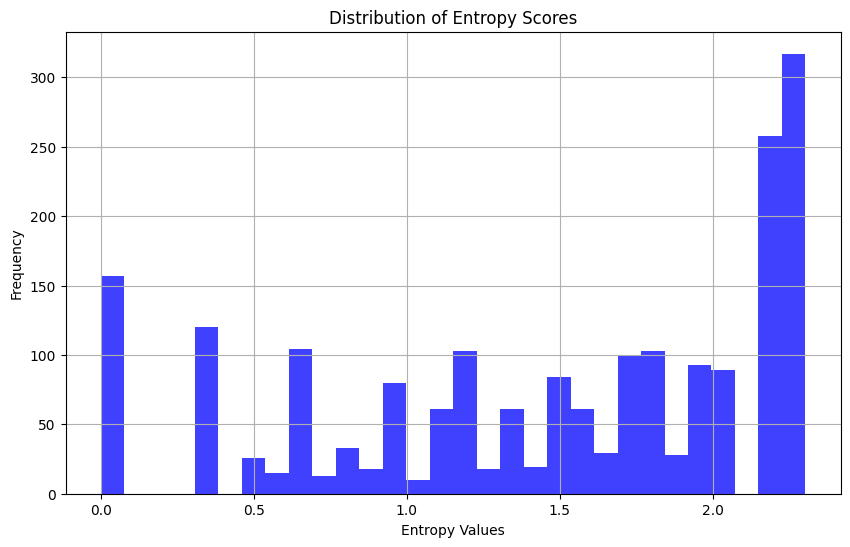

In [10]:
# Plot the entropy distribution
def plot_entropy_distribution(entropies):
    entropies_np = entropies.numpy()
    plt.figure(figsize=(10, 6))  # Set the figure size
    plt.hist(entropies_np, bins=30, alpha=0.75, color='blue')
    plt.title('Distribution of Entropy Scores')  # Title of the histogram
    plt.xlabel('Entropy Values')  # Label for the x-axis
    plt.ylabel('Frequency')  # Label for the y-axis
    plt.grid(True) 
    plt.show()

plot_entropy_distribution(entropy)

1.3024723939655658

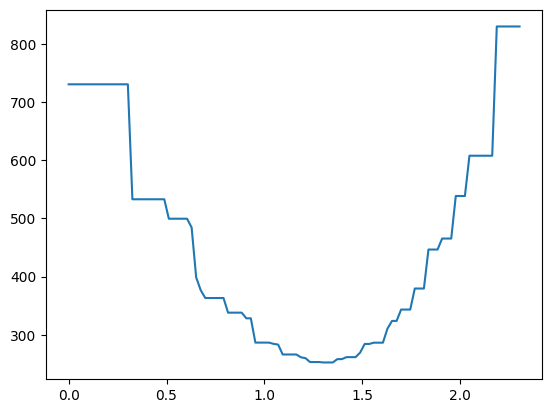

In [11]:
# Use best split approach (from Zebra notebook)
ents = entropy.numpy()
splits = np.linspace(1e-10, ents.max(), 100)
split_mses = []
for split in splits:
    low_idxs, high_idxs = ents < split, ents >= split

    low_mean = np.mean(ents[low_idxs])
    high_mean = np.mean(ents[high_idxs])

    mse = np.sum((ents[low_idxs] - low_mean)**2) + np.sum((ents[high_idxs] - high_mean)**2)
    mse = np.sum(mse)

    split_mses.append(mse)

split_mses = np.array(split_mses)

plt.plot(splits, split_mses)
splits[np.argmin(split_mses)]

In [12]:
def binarize_entropy(entropy, thres=0.0):  # 0.0 means even splits for normalized entropy scores
    """Binarize entropy scores into 0's and 1's"""
    binary_entropy = torch.full_like(entropy, -1, dtype=torch.float)
    binary_entropy[entropy < thres] = 0
    binary_entropy[entropy > thres] = 1

    return binary_entropy

bca_entropy = binarize_entropy(entropy, splits[np.argmin(split_mses)])
# bca_entropy = binarize_entropy(ca_entropy, 0.0)
print(f"Dummy accuracy: {max(torch.mean(bca_entropy).item(), 1-torch.mean(bca_entropy).item()):.4f}")

Dummy accuracy: 0.6210


In [13]:
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(tok_bef_gen_layered_datasets, bca_entropy, total_size)

In [14]:
# Training with LR.
tblr_test_accs = []
tblr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    tblr_test_accs.append(test_acc)
    tblr_test_aucs.append(test_auc)

Training on Dataset 1/33
Validation Accuracy: 0.6583, AUROC: 0.6377
Training Loss: 0.4995, Validation Loss: 0.6368
Test Loss: 0.6814, Test Accuracy: 0.6350, AUROC: 0.6225
Training on Dataset 2/33
Validation Accuracy: 0.6556, AUROC: 0.6424
Training Loss: 0.4525, Validation Loss: 0.6528
Test Loss: 0.6921, Test Accuracy: 0.6150, AUROC: 0.6317
Training on Dataset 3/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6417, AUROC: 0.6333
Training Loss: 0.3697, Validation Loss: 0.7219
Test Loss: 0.6840, Test Accuracy: 0.6350, AUROC: 0.6570
Training on Dataset 4/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6500, AUROC: 0.6554
Training Loss: 0.3230, Validation Loss: 0.9013
Test Loss: 0.7138, Test Accuracy: 0.6250, AUROC: 0.6543
Training on Dataset 5/33


...

Validation Accuracy: 0.7444, AUROC: 0.8066
Training Loss: 0.0005, Validation Loss: 1.4513
Test Loss: 1.8471, Test Accuracy: 0.6700, AUROC: 0.7484
Training on Dataset 30/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7222, AUROC: 0.7844
Training Loss: 0.0004, Validation Loss: 1.4230
Test Loss: 2.0494, Test Accuracy: 0.6950, AUROC: 0.7247
Training on Dataset 31/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7306, AUROC: 0.8010
Training Loss: 0.0003, Validation Loss: 1.4011
Test Loss: 2.0845, Test Accuracy: 0.6700, AUROC: 0.7255
Training on Dataset 32/33
Validation Accuracy: 0.7361, AUROC: 0.8221
Training Loss: 0.0003, Validation Loss: 1.3580
Test Loss: 2.0660, Test Accuracy: 0.6600, AUROC: 0.7355
Training on Dataset 33/33
Validation Accuracy: 0.7583, AUROC: 0.8138
Training Loss: 0.0022, Validation Loss: 1.1091
Test Loss: 1.5493, Test Accuracy: 0.6650, AUROC: 0.7062


In [15]:
print(f"LR on TBG embeddings and b-SE: best AUROC {max(tblr_test_aucs):.4f} at layer {np.argmax(tblr_test_aucs)+1}")

LR on TBG embeddings and b-SE: best AUROC 0.8148 at layer 16


In [16]:
def concat_Xs_and_ys(layer_range, X_trains, X_vals, X_tests, y_trains, y_vals, y_tests):
    X_train_cc = np.concatenate(np.array(X_trains)[layer_range], axis=1)
    X_val_cc = np.concatenate(np.array(X_vals)[layer_range], axis=1)
    X_test_cc = np.concatenate(np.array(X_tests)[layer_range], axis=1)
    y_train_cc = y_trains[layer_range[0]]
    y_val_cc = y_vals[layer_range[0]]
    y_test_cc = y_tests[layer_range[0]]
    return X_train_cc, X_val_cc, X_test_cc, y_train_cc, y_val_cc, y_test_cc

In [17]:
# Save models for testing on Accuracy
tblr_best_auc_indices = np.argsort(tblr_test_aucs)[::-1]

topktblr_test_accs = {}
topktblr_test_aucs = {}
topktblr_models = {}

for top_k in range(1, 10):
    indices = tblr_best_auc_indices[:top_k]
    print(f"Training on top-{top_k} Datasets indexed", list(indices+1))
    X_train, X_val, X_test, y_train, y_val, y_test = concat_Xs_and_ys(list(indices), X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on {top_k} Datasets")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    topktblr_test_accs[tuple(indices)] = test_acc
    topktblr_test_aucs[tuple(indices)] = test_auc
    topktblr_models[tuple(indices)] = model

Training on top-1 Datasets indexed [16]


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7500, AUROC: 0.7944
Training Loss: 0.0158, Validation Loss: 1.1686
Test Loss: 0.9230, Test Accuracy: 0.7300, AUROC: 0.8148
Training on top-2 Datasets indexed [16, 19]


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7583, AUROC: 0.8115
Training Loss: 0.0049, Validation Loss: 1.2720
Test Loss: 1.1642, Test Accuracy: 0.7400, AUROC: 0.8046
Training on top-3 Datasets indexed [16, 19, 20]


...

Validation Accuracy: 0.7583, AUROC: 0.8226
Training Loss: 0.0009, Validation Loss: 1.5152
Test Loss: 1.5649, Test Accuracy: 0.7150, AUROC: 0.7915
Training on top-8 Datasets indexed [16, 19, 20, 17, 21, 18, 22, 11]


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7528, AUROC: 0.8243
Training Loss: 0.0012, Validation Loss: 1.5313
Test Loss: 1.6107, Test Accuracy: 0.7000, AUROC: 0.7903
Training on top-9 Datasets indexed [16, 19, 20, 17, 21, 18, 22, 11, 24]


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7861, AUROC: 0.8477
Training Loss: 0.0005, Validation Loss: 1.3590
Test Loss: 1.5853, Test Accuracy: 0.7150, AUROC: 0.7945


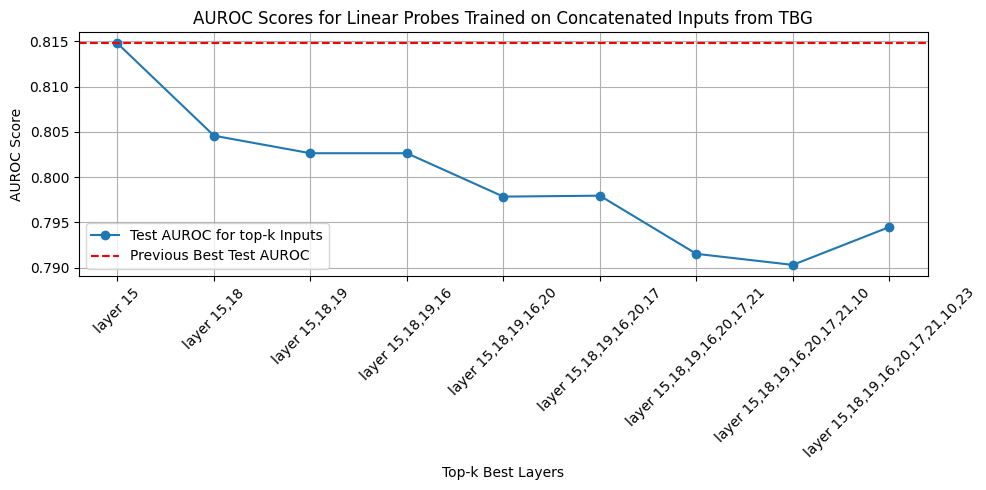

0.8147694818441453


In [18]:
# Plot the concat-ed trained AUROC scores and the previous best score
plot_metrics_w_constant(max(tblr_test_aucs), topktblr_test_aucs, 'TBG')
print(max(topktblr_test_aucs.values()))

### Explore Second Last generated Token (SLT)


In [20]:
sec_last_tok_dataset = torch.stack([record['most_likely_answer']['emb_tok_before_eos'] 
                                   for record in generations.values()]).squeeze(-2).to(torch.float32)
print(sec_last_tok_dataset.shape)

torch.Size([2000, 33, 3072])


In [21]:
sec_last_tok_dataset.transpose(0, 1).shape

torch.Size([33, 2000, 3072])

In [22]:
slt_layered_datasets = sec_last_tok_dataset.transpose(0, 1)
print(slt_layered_datasets.shape, slt_layered_datasets.dtype)

torch.Size([33, 2000, 3072]) torch.float32


In [18]:
# We may want to drop the first layer due to its homogeneity in values.
# print(slt_layered_datasets[0], slt_layered_datasets[0].shape)
# slt_layered_datasets = slt_layered_datasets[1:]

In [23]:
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(slt_layered_datasets, bca_entropy, total_size)

In [24]:
# Training with LR.
sblr_test_accs = []
sblr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    sblr_test_accs.append(test_acc)
    sblr_test_aucs.append(test_auc)

Training on Dataset 1/33
Validation Accuracy: 0.6139, AUROC: 0.5000
Training Loss: 0.6590, Validation Loss: 0.6675
Test Loss: 0.6908, Test Accuracy: 0.5700, AUROC: 0.5000
Training on Dataset 2/33
Validation Accuracy: 0.6139, AUROC: 0.6839
Training Loss: 0.6545, Validation Loss: 0.6621
Test Loss: 0.6894, Test Accuracy: 0.5700, AUROC: 0.5645
Training on Dataset 3/33
Validation Accuracy: 0.6139, AUROC: 0.6869
Training Loss: 0.6416, Validation Loss: 0.6470
Test Loss: 0.6841, Test Accuracy: 0.5750, AUROC: 0.5719
Training on Dataset 4/33
Validation Accuracy: 0.6472, AUROC: 0.7370
Training Loss: 0.6114, Validation Loss: 0.6133
Test Loss: 0.6670, Test Accuracy: 0.5750, AUROC: 0.6311
Training on Dataset 5/33
Validation Accuracy: 0.6611, AUROC: 0.7465
Training Loss: 0.5664, Validation Loss: 0.5863
Test Loss: 0.6619, Test Accuracy: 0.6050, AUROC: 0.6485
Training on Dataset 6/33
Validation Accuracy: 0.6556, AUROC: 0.7537
Training Loss: 0.5459, Validation Loss: 0.5764
Test Loss: 0.6602, Test Accura

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6861, AUROC: 0.7676
Training Loss: 0.4989, Validation Loss: 0.5658
Test Loss: 0.6437, Test Accuracy: 0.6750, AUROC: 0.6967
Training on Dataset 8/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7333, AUROC: 0.7876
Training Loss: 0.4290, Validation Loss: 0.5461
Test Loss: 0.6462, Test Accuracy: 0.6650, AUROC: 0.7210
Training on Dataset 9/33


...

Validation Accuracy: 0.7639, AUROC: 0.8426
Training Loss: 0.0015, Validation Loss: 1.4106
Test Loss: 1.9613, Test Accuracy: 0.7300, AUROC: 0.7782
Training on Dataset 25/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7583, AUROC: 0.8366
Training Loss: 0.0010, Validation Loss: 1.4822
Test Loss: 1.9922, Test Accuracy: 0.7300, AUROC: 0.7719
Training on Dataset 26/33
Validation Accuracy: 0.7722, AUROC: 0.8420
Training Loss: 0.0007, Validation Loss: 1.4773
Test Loss: 2.0677, Test Accuracy: 0.7000, AUROC: 0.7699
Training on Dataset 27/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7611, AUROC: 0.8400
Training Loss: 0.0005, Validation Loss: 1.4364
Test Loss: 2.0560, Test Accuracy: 0.7500, AUROC: 0.7858
Training on Dataset 28/33
Validation Accuracy: 0.7444, AUROC: 0.8356
Training Loss: 0.0004, Validation Loss: 1.4429
Test Loss: 2.2259, Test Accuracy: 0.6950, AUROC: 0.7600
Training on Dataset 29/33
Validation Accuracy: 0.7889, AUROC: 0.8485
Training Loss: 0.0003, Validation Loss: 1.4524
Test Loss: 2.0893, Test Accuracy: 0.7150, AUROC: 0.7749
Training on Dataset 30/33
Validation Accuracy: 0.7750, AUROC: 0.8416
Training Loss: 0.0003, Validation Loss: 1.6037
Test Loss: 2.1432, Test Accuracy: 0.7100, AUROC: 0.7806
Training on Dataset 31/33
Validation Accuracy: 0.7722, AUROC: 0.8494
Training Loss: 0.0002, Validation Loss: 1.4160
Test Loss: 1.9647, Test Accuracy: 0.7050, AUROC: 0.7854
Training on Dataset 32/33
Validation Accuracy: 0.7889, AUROC: 0.8624
Training Loss: 0.0002, Validation Loss: 1.4487
Test Loss: 2.3192, Test Accuracy: 0.6850, AUROC: 0

In [25]:
print(f"LR on SLT embeddings and b-SE: best AUROC {max(sblr_test_aucs):.4f} at layer {np.argmax(sblr_test_aucs)+1}")

LR on SLT embeddings and b-SE: best AUROC 0.8046 at layer 22


In [26]:
# Select best top-k layers 
sblr_best_auc_indices = np.argsort(sblr_test_aucs)[::-1]

topksblr_test_accs = {}
topksblr_test_aucs = {}
topksblr_models = {}

for top_k in range(1, 10):
    indices = sblr_best_auc_indices[:top_k]
    print(f"Training on top-{top_k} Datasets indexed", list(indices+1))
    X_train, X_val, X_test, y_train, y_val, y_test = concat_Xs_and_ys(list(indices), X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on {top_k} Datasets")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    topksblr_test_accs[tuple(indices)] = test_acc
    topksblr_test_aucs[tuple(indices)] = test_auc
    topksblr_models[tuple(indices)] = model

Training on top-1 Datasets indexed [22]


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7750, AUROC: 0.8459
Training Loss: 0.0043, Validation Loss: 1.2374
Test Loss: 1.3587, Test Accuracy: 0.7500, AUROC: 0.8046
Training on top-2 Datasets indexed [22, 21]


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7889, AUROC: 0.8428
Training Loss: 0.0028, Validation Loss: 1.3457
Test Loss: 1.4743, Test Accuracy: 0.7500, AUROC: 0.8026
Training on top-3 Datasets indexed [22, 21, 20]


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7750, AUROC: 0.8436
Training Loss: 0.0020, Validation Loss: 1.2908
Test Loss: 1.4275, Test Accuracy: 0.7650, AUROC: 0.8040
Training on top-4 Datasets indexed [22, 21, 20, 23]


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7611, AUROC: 0.8475
Training Loss: 0.0012, Validation Loss: 1.4380
Test Loss: 1.7586, Test Accuracy: 0.7500, AUROC: 0.7999
Training on top-5 Datasets indexed [22, 21, 20, 23, 27]
Validation Accuracy: 0.7722, AUROC: 0.8525
Training Loss: 0.0003, Validation Loss: 1.3244
Test Loss: 1.7900, Test Accuracy: 0.7700, AUROC: 0.8011
Training on top-6 Datasets indexed [22, 21, 20, 23, 27, 31]
Validation Accuracy: 0.7833, AUROC: 0.8686
Training Loss: 0.0001, Validation Loss: 1.2697
Test Loss: 1.9411, Test Accuracy: 0.7500, AUROC: 0.8020
Training on top-7 Datasets indexed [22, 21, 20, 23, 27, 31, 30]
Validation Accuracy: 0.7722, AUROC: 0.8631
Training Loss: 0.0001, Validation Loss: 1.5121
Test Loss: 2.2385, Test Accuracy: 0.7500, AUROC: 0.7968
Training on top-8 Datasets indexed [22, 21, 20, 23, 27, 31, 30, 24]
Validation Accuracy: 0.7806, AUROC: 0.8646
Training Loss: 0.0001, Validation Loss: 1.5778
Test Loss: 2.3722, Test Accuracy: 0.7400, AUROC: 0.7984
Training on top-9 Data

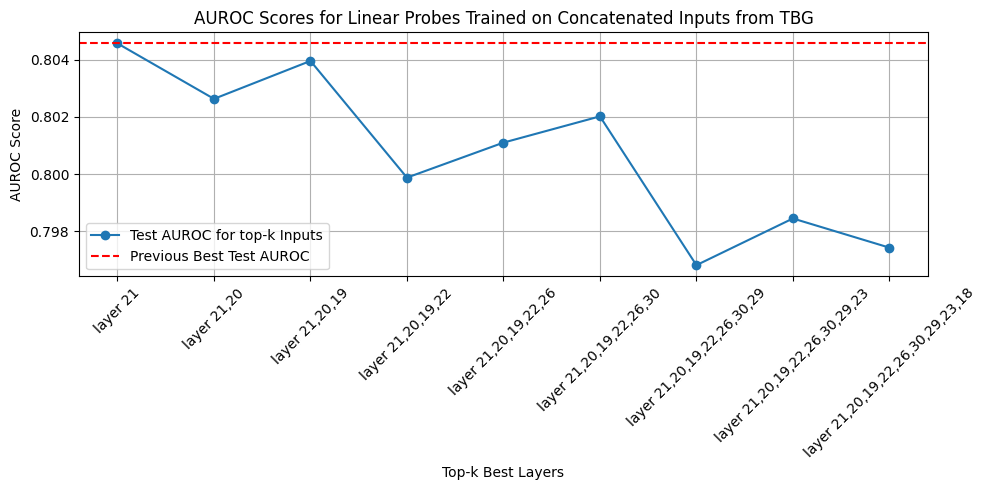

0.8045695634434923


In [27]:
# Plot the concat-ed trained AUROC scores and the previous best score
plot_metrics_w_constant(max(sblr_test_aucs), topksblr_test_aucs, 'TBG')
print(max(topksblr_test_aucs.values()))

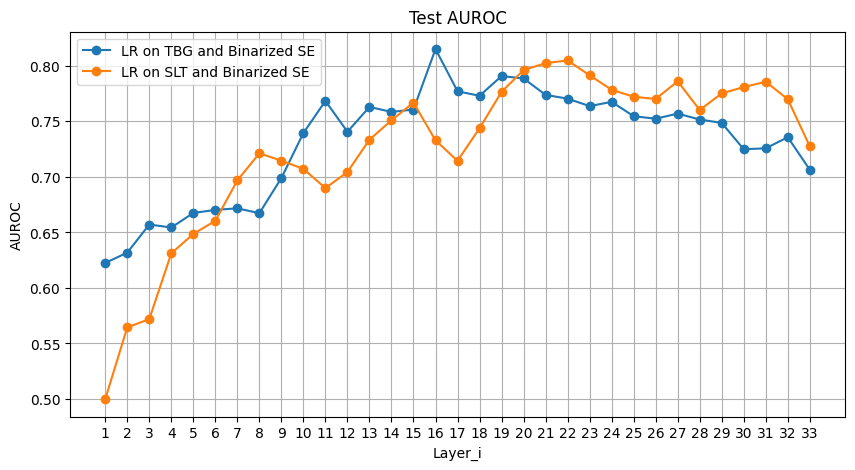

TBG: max AUROC for LR trained and tested on Binarized SE: 0.8148 at 16 layer
SLT: max AUROC for LR trained and tested on Binarized SE: 0.8046 at 22 layer


In [28]:
plot_1d_metrics([tblr_test_aucs, sblr_test_aucs], ['LR on TBG and Binarized SE', 'LR on SLT and Binarized SE'], 'AUROC')
print(f"TBG: max AUROC for LR trained and tested on Binarized SE: {max(tblr_test_aucs):.4f} at {np.argmax(tblr_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR trained and tested on Binarized SE: {max(sblr_test_aucs):.4f} at {np.argmax(sblr_test_aucs)+1} layer")

## Use Linear Probe for Predicting Correctness of Generated Answers (or Accuracy)

It would be interesting to see how linear probes perform at predicting accuracy obtained from using semantic entropy at selecting the most probable answer (true or false), as indicated in the `compute_uncertainty_measures.py` (_# For the semantic uncertainties, we can also change the prediction, by first selecting the semantic cluster with the highest probability, and then selecting the generation with the highest probability within that cluster._)

We will use logistic regression for this task, as for the binarized entropy prediction task.

### Token Before first Generation (TBG)

In [29]:
accuracies = torch.tensor([record['most_likely_answer']['accuracy'] for record in generations.values()])
print(accuracies.shape, accuracies[:10])  # "Accuracies" are binary. Classification task.

torch.Size([2000]) tensor([0., 1., 0., 0., 0., 0., 0., 0., 0., 1.])


In [30]:
# Prepare X's and y's for sklearn LR model.
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(tok_bef_gen_layered_datasets, accuracies, total_size)

In [31]:
# Dummy accuracy:
print(f"Dummy accuracy: {max(np.mean(y_tests), 1-np.mean(y_tests)):.4f}")

Dummy accuracy: 0.7200


In [32]:
# Training Loops (LR)
talr_test_accs = []
talr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on TBG-Acc Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on TBG-Acc Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    talr_test_accs.append(test_acc)
    talr_test_aucs.append(test_auc)

Training on TBG-Acc Dataset 1/33
Validation Accuracy: 0.7389, AUROC: 0.5612
Training Loss: 0.4366, Validation Loss: 0.5774
Test Loss: 0.5950, Test Accuracy: 0.7100, AUROC: 0.5747
Training on TBG-Acc Dataset 2/33
Validation Accuracy: 0.7389, AUROC: 0.5799
Training Loss: 0.3969, Validation Loss: 0.5845
Test Loss: 0.6102, Test Accuracy: 0.6850, AUROC: 0.5692
Training on TBG-Acc Dataset 3/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7167, AUROC: 0.5756
Training Loss: 0.3322, Validation Loss: 0.6257
Test Loss: 0.6632, Test Accuracy: 0.6800, AUROC: 0.5432
Training on TBG-Acc Dataset 4/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7028, AUROC: 0.5759
Training Loss: 0.2921, Validation Loss: 0.7615
Test Loss: 0.6914, Test Accuracy: 0.6700, AUROC: 0.5472
Training on TBG-Acc Dataset 5/33


...

Validation Accuracy: 0.7028, AUROC: 0.6711
Training Loss: 0.0015, Validation Loss: 1.8698
Test Loss: 1.7738, Test Accuracy: 0.7200, AUROC: 0.6844
Training on TBG-Acc Dataset 25/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6889, AUROC: 0.6672
Training Loss: 0.0010, Validation Loss: 1.8899
Test Loss: 1.9730, Test Accuracy: 0.7050, AUROC: 0.6530
Training on TBG-Acc Dataset 26/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6917, AUROC: 0.6613
Training Loss: 0.0008, Validation Loss: 1.9298
Test Loss: 1.9229, Test Accuracy: 0.6850, AUROC: 0.6478
Training on TBG-Acc Dataset 27/33
Validation Accuracy: 0.7139, AUROC: 0.6715
Training Loss: 0.0006, Validation Loss: 1.9017
Test Loss: 1.9113, Test Accuracy: 0.6850, AUROC: 0.6512
Training on TBG-Acc Dataset 28/33
Validation Accuracy: 0.6833, AUROC: 0.6436
Training Loss: 0.0005, Validation Loss: 2.0048
Test Loss: 1.9799, Test Accuracy: 0.7150, AUROC: 0.6664
Training on TBG-Acc Dataset 29/33
Validation Accuracy: 0.7167, AUROC: 0.6700
Training Loss: 0.0004, Validation Loss: 1.9056
Test Loss: 2.1166, Test Accuracy: 0.6700, AUROC: 0.6517
Training on TBG-Acc Dataset 30/33
Validation Accuracy: 0.7167, AUROC: 0.6708
Training Loss: 0.0003, Validation Loss: 1.9161
Test Loss: 1.9180, Test Accuracy: 0.6950, AUROC: 0.6941
Training on TBG-Acc Dataset 31/33
Validation Accuracy: 0.7167, AUROC: 0.6876
Training Loss: 0.0003, Validation Loss: 1.8891
Test Loss:

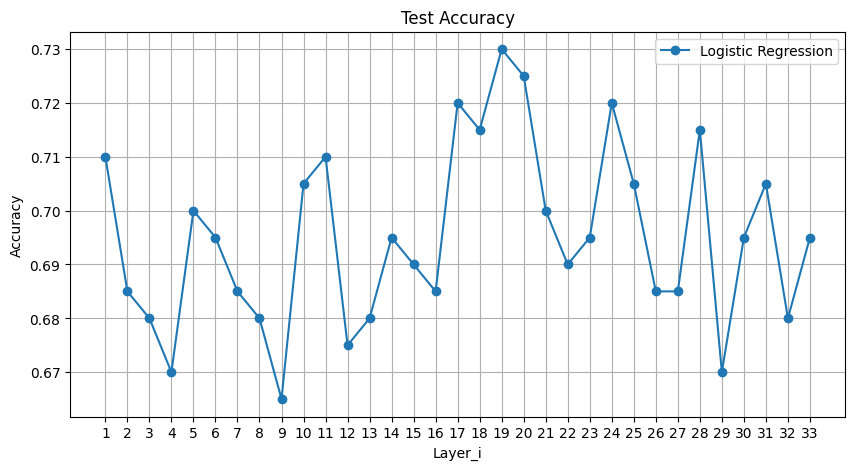

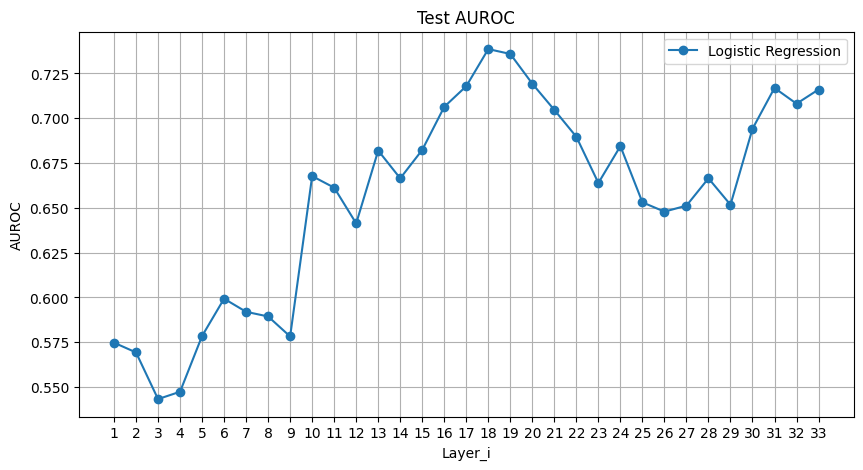

In [33]:
plot_1d_metrics([talr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([talr_test_aucs], ['Logistic Regression'], 'AUROC')

In [34]:
print(f"LR on TBG embeddings and Accuracy: best AUROC {max(talr_test_aucs):.4f} at layer {np.argmax(talr_test_aucs)+1}")

LR on TBG embeddings and Accuracy: best AUROC 0.7386 at layer 18


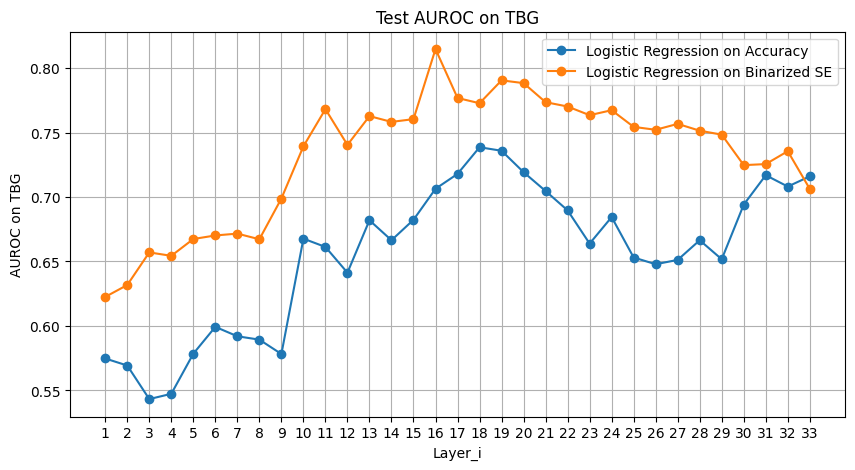

TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.7386 at 18 layer
TBG: max AUROC for LR trained on Binary SE, tested on Binary SE: 0.8148 at 16 layer


In [35]:
plot_1d_metrics([talr_test_aucs, tblr_test_aucs], ['Logistic Regression on Accuracy', 'Logistic Regression on Binarized SE'], 'AUROC on TBG')
print(f"TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(talr_test_aucs):.4f} at {np.argmax(talr_test_aucs)+1} layer")
print(f"TBG: max AUROC for LR trained on Binary SE, tested on Binary SE: {max(tblr_test_aucs):.4f} at {np.argmax(tblr_test_aucs)+1} layer")

In [36]:
# Data for SLT embeddings
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(slt_layered_datasets, accuracies, total_size)

In [37]:
# Training with LR.
salr_test_accs = []
salr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on SLT-Acc Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on SLT-Acc Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    salr_test_accs.append(test_acc)
    salr_test_aucs.append(test_auc)

Training on SLT-Acc Dataset 1/33
Validation Accuracy: 0.7389, AUROC: 0.5000
Training Loss: 0.5720, Validation Loss: 0.5742
Test Loss: 0.5941, Test Accuracy: 0.7200, AUROC: 0.5000
Training on SLT-Acc Dataset 2/33
Validation Accuracy: 0.7389, AUROC: 0.5859
Training Loss: 0.5701, Validation Loss: 0.5728
Test Loss: 0.5926, Test Accuracy: 0.7200, AUROC: 0.5970
Training on SLT-Acc Dataset 3/33
Validation Accuracy: 0.7389, AUROC: 0.5898
Training Loss: 0.5652, Validation Loss: 0.5689
Test Loss: 0.5865, Test Accuracy: 0.7200, AUROC: 0.6062
Training on SLT-Acc Dataset 4/33
Validation Accuracy: 0.7389, AUROC: 0.6290
Training Loss: 0.5546, Validation Loss: 0.5606
Test Loss: 0.5730, Test Accuracy: 0.7200, AUROC: 0.6777
Training on SLT-Acc Dataset 5/33
Validation Accuracy: 0.7472, AUROC: 0.6094
Training Loss: 0.5318, Validation Loss: 0.5608
Test Loss: 0.5631, Test Accuracy: 0.7200, AUROC: 0.6524
Training on SLT-Acc Dataset 6/33
Validation Accuracy: 0.7444, AUROC: 0.6060
Training Loss: 0.5169, Valida

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7278, AUROC: 0.6317
Training Loss: 0.4836, Validation Loss: 0.5610
Test Loss: 0.5337, Test Accuracy: 0.7350, AUROC: 0.7200
Training on SLT-Acc Dataset 8/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7139, AUROC: 0.6691
Training Loss: 0.4178, Validation Loss: 0.5730
Test Loss: 0.5392, Test Accuracy: 0.7350, AUROC: 0.7060
Training on SLT-Acc Dataset 9/33


...

Validation Accuracy: 0.7028, AUROC: 0.7073
Training Loss: 0.0007, Validation Loss: 1.7611
Test Loss: 1.5307, Test Accuracy: 0.7450, AUROC: 0.7645
Training on SLT-Acc Dataset 28/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7028, AUROC: 0.6809
Training Loss: 0.0005, Validation Loss: 1.8766
Test Loss: 1.5441, Test Accuracy: 0.7500, AUROC: 0.7551
Training on SLT-Acc Dataset 29/33
Validation Accuracy: 0.7000, AUROC: 0.6939
Training Loss: 0.0004, Validation Loss: 1.9014
Test Loss: 1.5256, Test Accuracy: 0.7700, AUROC: 0.7567
Training on SLT-Acc Dataset 30/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7278, AUROC: 0.6925
Training Loss: 0.0003, Validation Loss: 1.8805
Test Loss: 1.7010, Test Accuracy: 0.7600, AUROC: 0.7269
Training on SLT-Acc Dataset 31/33
Validation Accuracy: 0.7389, AUROC: 0.7128
Training Loss: 0.0002, Validation Loss: 1.8608
Test Loss: 1.7873, Test Accuracy: 0.7400, AUROC: 0.7264
Training on SLT-Acc Dataset 32/33
Validation Accuracy: 0.7222, AUROC: 0.7102
Training Loss: 0.0002, Validation Loss: 1.9669
Test Loss: 1.9996, Test Accuracy: 0.7200, AUROC: 0.7123
Training on SLT-Acc Dataset 33/33
Validation Accuracy: 0.7194, AUROC: 0.6815
Training Loss: 0.0029, Validation Loss: 1.5443
Test Loss: 1.3868, Test Accuracy: 0.6750, AUROC: 0.6918


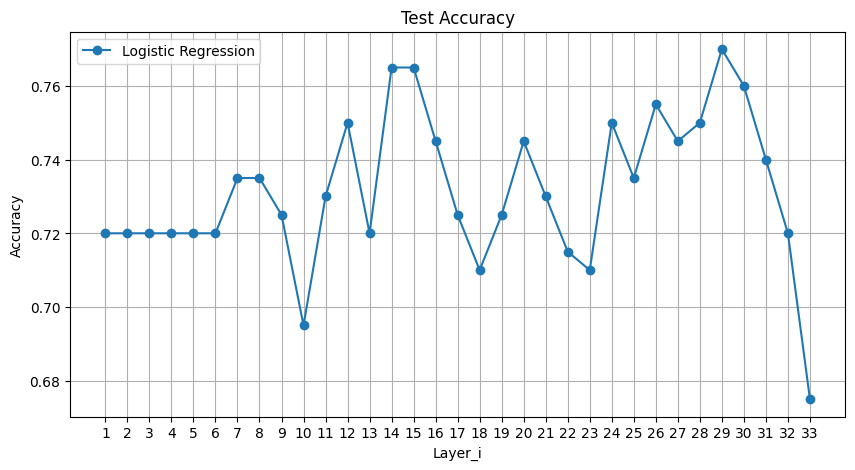

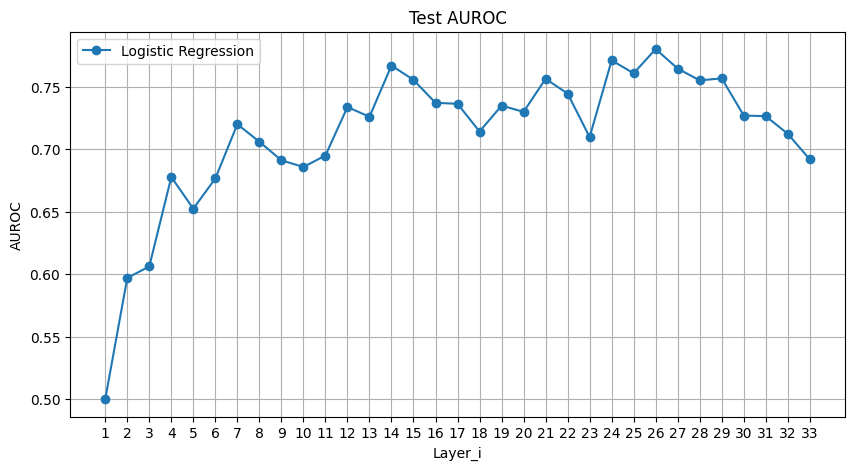

In [38]:
plot_1d_metrics([salr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([salr_test_aucs], ['Logistic Regression'], 'AUROC')

In [39]:
print(f"LR on SLT embeddings and Accuracy: best AUROC {max(salr_test_aucs):.4f} at layer {np.argmax(salr_test_aucs)+1}")

LR on SLT embeddings and Accuracy: best AUROC 0.7801 at layer 26


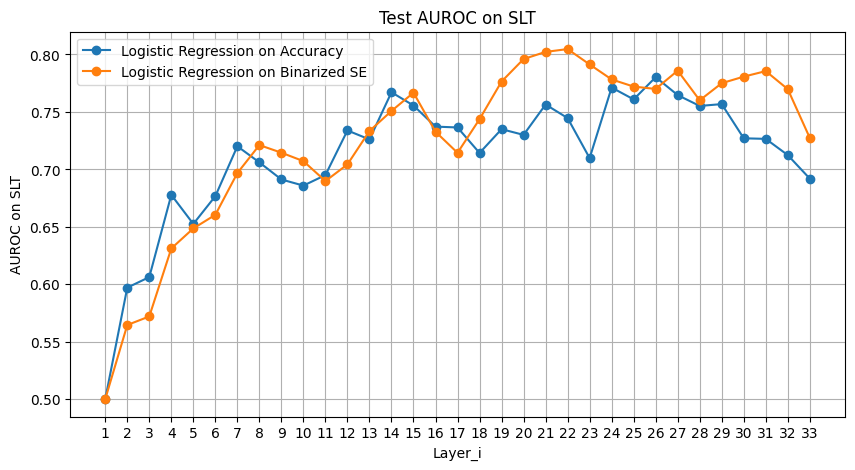

SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.7801 at 26 layer
SLT: max AUROC for LR trained on Binary SE, tested on Binary SE: 0.8046 at 22 layer


In [40]:
plot_1d_metrics([salr_test_aucs, sblr_test_aucs], ['Logistic Regression on Accuracy', 'Logistic Regression on Binarized SE'], 'AUROC on SLT')
print(f"SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(salr_test_aucs):.4f} at {np.argmax(salr_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR trained on Binary SE, tested on Binary SE: {max(sblr_test_aucs):.4f} at {np.argmax(sblr_test_aucs)+1} layer")

#### Compare TBG and SLT at predicting Acc

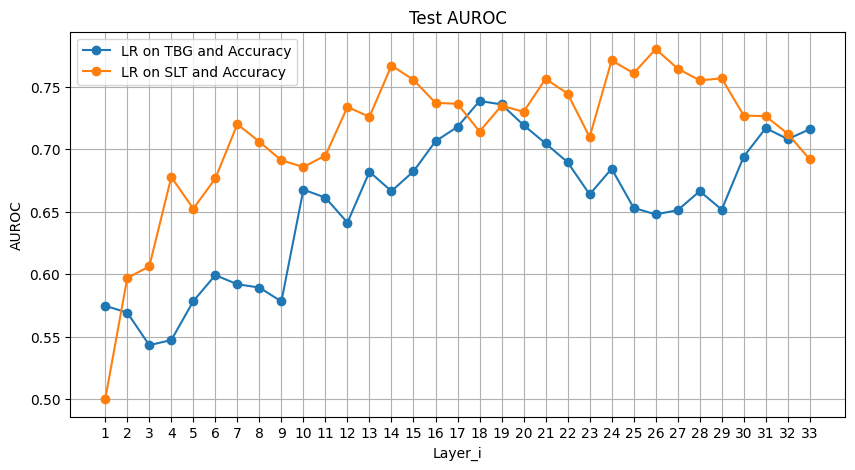

TBG: max AUROC for LR trained and tested on Accuracy: 0.7386 at 18 layer
SLT: max AUROC for LR trained and tested on Accuracy: 0.7801 at 26 layer


In [41]:
plot_1d_metrics([talr_test_aucs, salr_test_aucs], ['LR on TBG and Accuracy', 'LR on SLT and Accuracy'], 'AUROC')
print(f"TBG: max AUROC for LR trained and tested on Accuracy: {max(talr_test_aucs):.4f} at {np.argmax(talr_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR trained and tested on Accuracy: {max(salr_test_aucs):.4f} at {np.argmax(salr_test_aucs)+1} layer")

## Use Classifier for Binary SE for Predicting LLM Accuracy

We want to show that models trained on binary SE are more generalizable to new datasets when predicting their generation correctness.

In [42]:
# Test with accuracy test set (with the same random seed to ensure no data leakage)
# We should reverse the accuracy due to negative R.
r_accuracies = 1 - accuracies

X_trains, X_vals, _, y_trains, y_vals, _ = create_Xs_and_ys(tok_bef_gen_layered_datasets, bca_entropy, total_size)
_, _, X_tests, _, _, y_tests = create_Xs_and_ys(tok_bef_gen_layered_datasets, r_accuracies, total_size)

In [43]:
# Training Loops (LR)
tablr_test_accs = []
tablr_test_aucs = []
tablr_trained_models = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on TBG Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on TBG Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    tablr_test_accs.append(test_acc)
    tablr_test_aucs.append(test_auc)
    tablr_trained_models.append(model)

Training on TBG Dataset 1/33
Validation Accuracy: 0.6583, AUROC: 0.6377
Training Loss: 0.4995, Validation Loss: 0.6368
Test Loss: 0.6231, Test Accuracy: 0.6550, AUROC: 0.5810
Training on TBG Dataset 2/33
Validation Accuracy: 0.6556, AUROC: 0.6424
Training Loss: 0.4525, Validation Loss: 0.6528
Test Loss: 0.6442, Test Accuracy: 0.6350, AUROC: 0.5815
Training on TBG Dataset 3/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6417, AUROC: 0.6333
Training Loss: 0.3697, Validation Loss: 0.7219
Test Loss: 0.6659, Test Accuracy: 0.5950, AUROC: 0.5841
Training on TBG Dataset 4/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6500, AUROC: 0.6554
Training Loss: 0.3230, Validation Loss: 0.9013
Test Loss: 0.7211, Test Accuracy: 0.6050, AUROC: 0.5826
Training on TBG Dataset 5/33


...

Validation Accuracy: 0.7444, AUROC: 0.8066
Training Loss: 0.0005, Validation Loss: 1.4513
Test Loss: 1.9374, Test Accuracy: 0.6900, AUROC: 0.7374
Training on TBG Dataset 30/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7222, AUROC: 0.7844
Training Loss: 0.0004, Validation Loss: 1.4230
Test Loss: 1.8309, Test Accuracy: 0.7050, AUROC: 0.7501
Training on TBG Dataset 31/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7306, AUROC: 0.8010
Training Loss: 0.0003, Validation Loss: 1.4011
Test Loss: 1.6894, Test Accuracy: 0.7100, AUROC: 0.7676
Training on TBG Dataset 32/33
Validation Accuracy: 0.7361, AUROC: 0.8221
Training Loss: 0.0003, Validation Loss: 1.3580
Test Loss: 1.8564, Test Accuracy: 0.7100, AUROC: 0.7687
Training on TBG Dataset 33/33
Validation Accuracy: 0.7583, AUROC: 0.8138
Training Loss: 0.0022, Validation Loss: 1.1091
Test Loss: 1.3167, Test Accuracy: 0.6950, AUROC: 0.7510


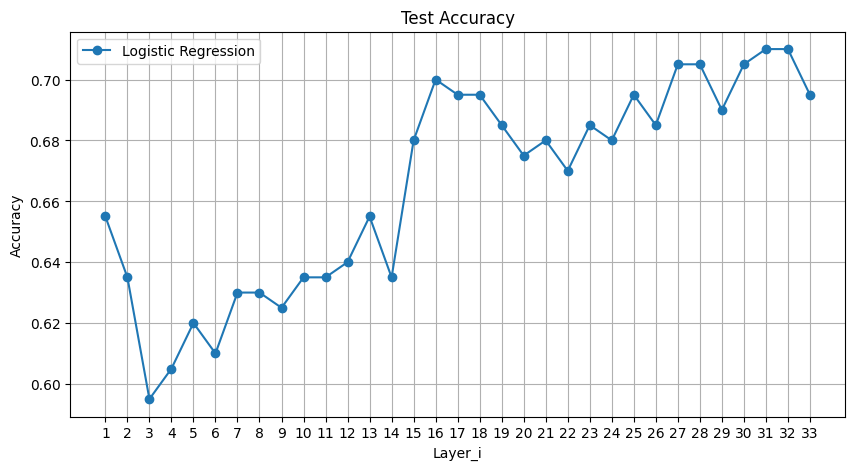

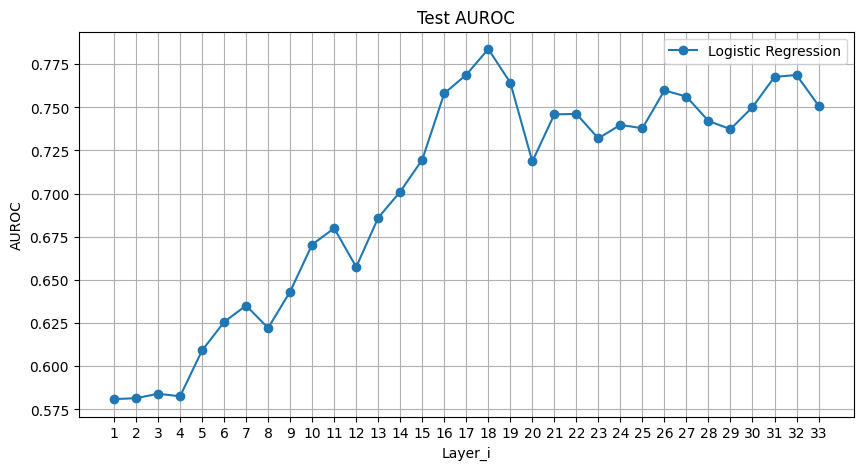

In [44]:
plot_1d_metrics([tablr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([tablr_test_aucs], ['Logistic Regression'], 'AUROC')

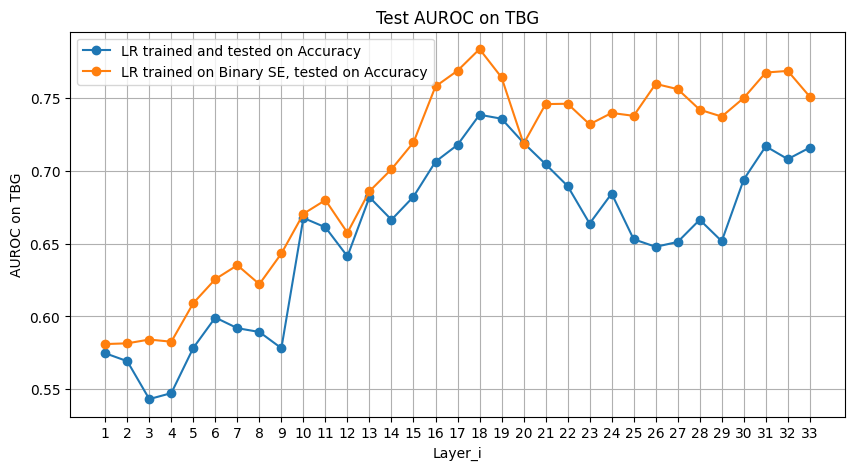

TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.7386 at 18 layer
TBG: max AUROC for LR trained on Binary SE, tested on Accuracy: 0.7837 at 18 layer


In [46]:
# Max AUROC achieved by 'transfer learning' compared to normal training
plot_1d_metrics([talr_test_aucs, tablr_test_aucs], ['LR trained and tested on Accuracy', 'LR trained on Binary SE, tested on Accuracy'], 'AUROC on TBG')
print(f"TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(talr_test_aucs):.4f} at {np.argmax(talr_test_aucs)+1} layer")
print(f"TBG: max AUROC for LR trained on Binary SE, tested on Accuracy: {max(tablr_test_aucs):.4f} at {np.argmax(tablr_test_aucs)+1} layer")

Now we test on SLT embeddings.

In [47]:
X_trains, X_vals, _, y_trains, y_vals, _ = create_Xs_and_ys(slt_layered_datasets, bca_entropy, total_size)
_, _, X_tests, _, _, y_tests = create_Xs_and_ys(slt_layered_datasets, r_accuracies, total_size)

In [48]:
# Training Loops (LR)
sablr_test_accs = []
sablr_test_aucs = []
sablr_trained_models = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on SLT Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on SLT Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    sablr_test_accs.append(test_acc)
    sablr_test_aucs.append(test_auc)
    sablr_trained_models.append(model)

Training on SLT Dataset 1/33
Validation Accuracy: 0.6139, AUROC: 0.5000
Training Loss: 0.6590, Validation Loss: 0.6675
Test Loss: 0.6111, Test Accuracy: 0.7200, AUROC: 0.5000
Training on SLT Dataset 2/33
Validation Accuracy: 0.6139, AUROC: 0.6839
Training Loss: 0.6545, Validation Loss: 0.6621
Test Loss: 0.6083, Test Accuracy: 0.7200, AUROC: 0.6277
Training on SLT Dataset 3/33
Validation Accuracy: 0.6139, AUROC: 0.6869
Training Loss: 0.6416, Validation Loss: 0.6470
Test Loss: 0.6007, Test Accuracy: 0.7250, AUROC: 0.6198
Training on SLT Dataset 4/33
Validation Accuracy: 0.6472, AUROC: 0.7370
Training Loss: 0.6114, Validation Loss: 0.6133
Test Loss: 0.5884, Test Accuracy: 0.6950, AUROC: 0.6616
Training on SLT Dataset 5/33
Validation Accuracy: 0.6611, AUROC: 0.7465
Training Loss: 0.5664, Validation Loss: 0.5863
Test Loss: 0.5886, Test Accuracy: 0.6950, AUROC: 0.6753
Training on SLT Dataset 6/33
Validation Accuracy: 0.6556, AUROC: 0.7537
Training Loss: 0.5459, Validation Loss: 0.5764
Test L

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.6861, AUROC: 0.7676
Training Loss: 0.4989, Validation Loss: 0.5658
Test Loss: 0.5691, Test Accuracy: 0.7150, AUROC: 0.7217
Training on SLT Dataset 8/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7333, AUROC: 0.7876
Training Loss: 0.4290, Validation Loss: 0.5461
Test Loss: 0.5556, Test Accuracy: 0.7050, AUROC: 0.7551
Training on SLT Dataset 9/33


...

Validation Accuracy: 0.7639, AUROC: 0.8426
Training Loss: 0.0015, Validation Loss: 1.4106
Test Loss: 2.0017, Test Accuracy: 0.7300, AUROC: 0.7747
Training on SLT Dataset 25/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7583, AUROC: 0.8366
Training Loss: 0.0010, Validation Loss: 1.4822
Test Loss: 1.6344, Test Accuracy: 0.7500, AUROC: 0.7971
Training on SLT Dataset 26/33
Validation Accuracy: 0.7722, AUROC: 0.8420
Training Loss: 0.0007, Validation Loss: 1.4773
Test Loss: 1.7962, Test Accuracy: 0.7000, AUROC: 0.7861
Training on SLT Dataset 27/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7611, AUROC: 0.8400
Training Loss: 0.0005, Validation Loss: 1.4364
Test Loss: 2.1267, Test Accuracy: 0.7000, AUROC: 0.7536
Training on SLT Dataset 28/33
Validation Accuracy: 0.7444, AUROC: 0.8356
Training Loss: 0.0004, Validation Loss: 1.4429
Test Loss: 2.2723, Test Accuracy: 0.6750, AUROC: 0.7247
Training on SLT Dataset 29/33
Validation Accuracy: 0.7889, AUROC: 0.8485
Training Loss: 0.0003, Validation Loss: 1.4524
Test Loss: 2.1489, Test Accuracy: 0.7050, AUROC: 0.7463
Training on SLT Dataset 30/33
Validation Accuracy: 0.7750, AUROC: 0.8416
Training Loss: 0.0003, Validation Loss: 1.6037
Test Loss: 2.1489, Test Accuracy: 0.7200, AUROC: 0.7563
Training on SLT Dataset 31/33
Validation Accuracy: 0.7722, AUROC: 0.8494
Training Loss: 0.0002, Validation Loss: 1.4160
Test Loss: 1.9669, Test Accuracy: 0.7050, AUROC: 0.7728
Training on SLT Dataset 32/33
Validation Accuracy: 0.7889, AUROC: 0.8624
Training Loss: 0.0002, Validation Loss: 1.4487
Test Loss: 2.1445, Test Accura

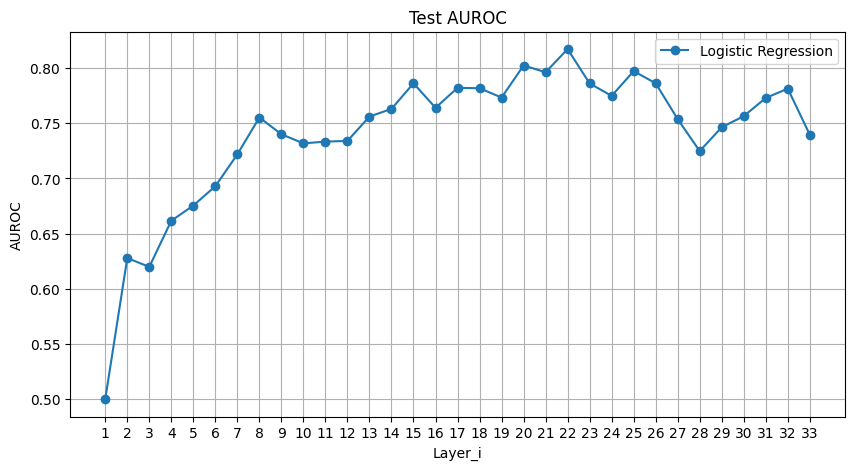

In [49]:
# plot_1d_metrics([sablr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([sablr_test_aucs], ['Logistic Regression'], 'AUROC')

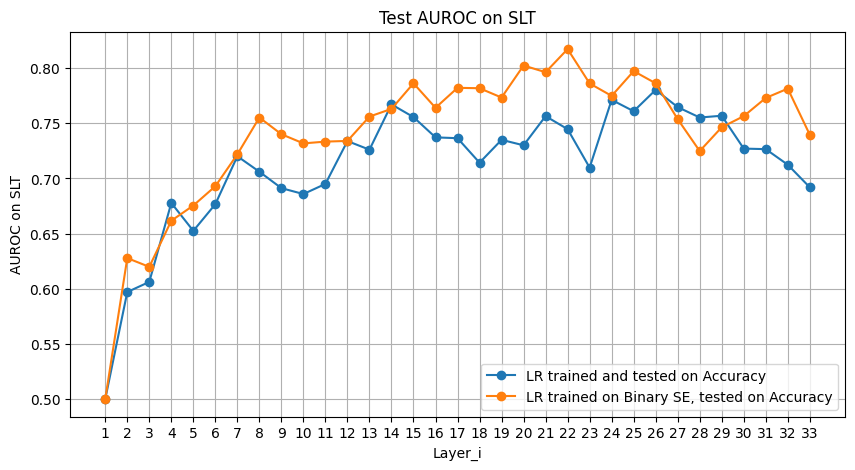

SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.7801 at 26 layer
SLT: max AUROC for LR trained on Binary SE, tested on Accuracy: 0.8171 at 22 layer


In [50]:
# Max AUROC achieved by 'transfer learning' compared to normal training
plot_1d_metrics([salr_test_aucs, sablr_test_aucs], ['LR trained and tested on Accuracy', 'LR trained on Binary SE, tested on Accuracy'], 'AUROC on SLT')
print(f"SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(salr_test_aucs):.4f} at {np.argmax(salr_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR trained on Binary SE, tested on Accuracy: {max(sablr_test_aucs):.4f} at {np.argmax(sablr_test_aucs)+1} layer")